# IS 352: Assignment 02 — Machine Learning Model Development
## House Price Prediction using Random Forest Regression
---

# REAGAN CHARLES REUBEN 30489/T.2023
# HAGAI JOHN MKAWE 30831/T.2023
# MESHAKI YUSUPH MPENDA 32001/T.2023
# BRITNEY BROWN NORMAN 30297/T.2023
# FARIJALA YAHAYA SAMBAYA 31148/T.2023
# EDMUND WILLIAM RWEGASIRA 31239/T.2023

## (a) Load and Explore the Dataset

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv('house_price_regression_dataset.csv')

# Display the first five records
print("First 5 Records:")
df.head()

First 5 Records:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [5]:
# Dataset size and data types
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Dataset Shape: 1000 rows x 8 columns

Data Types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

Basic Statistics:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


### Observations
The dataset contains **1000 records** and **8 columns**. All features are numerical. The target variable is `House_Price`, which represents the price of a house in dollars. There are no categorical variables in this dataset.

---
## (b) Data Cleaning and Preprocessing

In [6]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values per Column:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Total missing values: 0


In [7]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for any outliers using IQR on House_Price
Q1 = df['House_Price'].quantile(0.25)
Q3 = df['House_Price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['House_Price'] < Q1 - 1.5 * IQR) | (df['House_Price'] > Q3 + 1.5 * IQR)]
print(f"Outliers detected in House_Price: {len(outliers)}")

# No categorical variables to encode in this dataset
print("\nNo categorical variables found — no encoding needed.")

Duplicate rows: 0
Outliers detected in House_Price: 0

No categorical variables found — no encoding needed.


In [8]:
# Separate features and target
X = df.drop(columns=['House_Price'])
y = df['House_Price']

# Normalize/scale numerical features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Features after scaling (first 3 rows):")
X_scaled.head(3)

Features after scaling (first 3 rows):


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,-1.159803,-0.693836,-1.186699,-0.269122,-1.679278,-1.254658,-0.213126
1,1.160724,0.007008,1.252559,1.428045,1.522390,-0.027008,0.133420
2,0.618843,-1.394681,0.032930,1.428045,0.660422,-1.254658,1.173060


### Observations
The dataset is clean with **no missing values** and **no duplicate rows**. Since all features are already numerical, no categorical encoding was required. We applied **StandardScaler** to normalize the features so that all variables contribute equally to the model, regardless of their original units.

---
## (c) Correlation Matrix

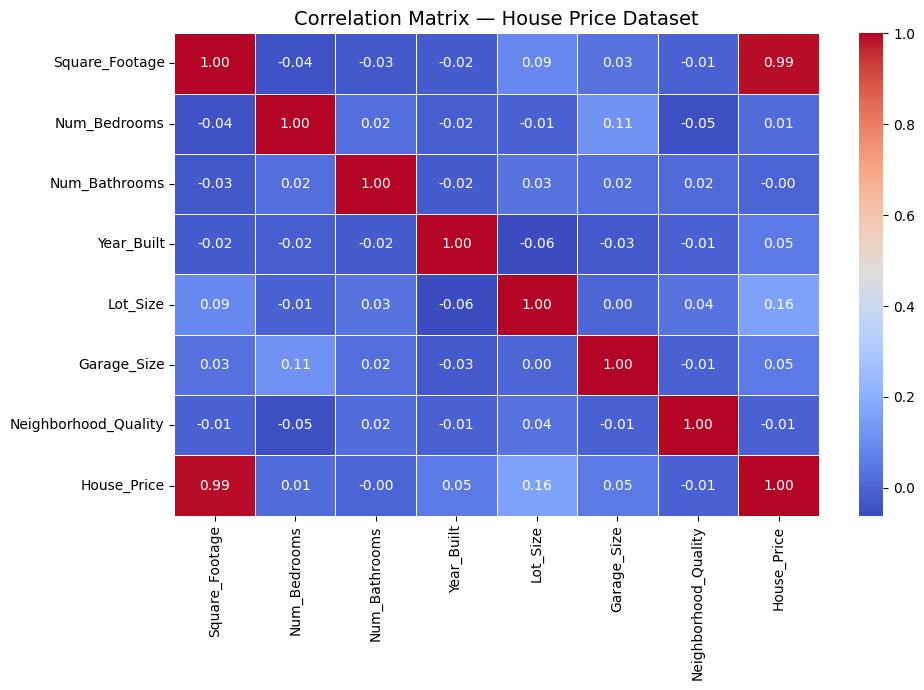

In [9]:
# Compute correlation matrix on full dataframe (including target)
corr_matrix = df.corr()

# Display as heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — House Price Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Identify variables most correlated with House_Price
print("Correlation with House_Price (sorted):")
print(corr_matrix['House_Price'].sort_values(ascending=False))

Correlation with House_Price (sorted):
House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


### Observations
From the correlation matrix, the features most strongly correlated with `House_Price` are:
- **Square_Footage** — strongest positive correlation, meaning larger homes cost more
- **Neighborhood_Quality** — higher quality neighborhoods are associated with higher prices
- **Num_Bathrooms** — more bathrooms tend to increase house value

Features like `Garage_Size` and `Lot_Size` show moderate correlation, while `Year_Built` and `Num_Bedrooms` have weaker relationships with price. This tells us that size and location quality are the primary price drivers.

---
## (d) Split the Dataset into Training and Testing Sets

In [11]:
# Split: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Training set size : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing set size  : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

Training set size : 700 samples (70%)
Testing set size  : 300 samples (30%)


---
## (e) Build a Machine Learning Model

We will train **two models** for comparison:
1. **Linear Regression** — simple baseline model
2. **Random Forest Regressor** — our primary model (handles non-linear relationships and feature interactions better)

In [12]:
# --- Model 1: Linear Regression (Baseline) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

# Show coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
print("\nFeature Coefficients:")
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

Linear Regression model trained successfully!

Feature Coefficients:
             Feature   Coefficient
      Square_Footage 250166.331273
          Year_Built  20679.265937
            Lot_Size  19257.610956
        Num_Bedrooms  14608.139620
       Num_Bathrooms   6815.300968
         Garage_Size   4237.550443
Neighborhood_Quality    381.589072


Random Forest model trained successfully!
Number of trees: 100


/tmp/ipykernel_141736/81674103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')


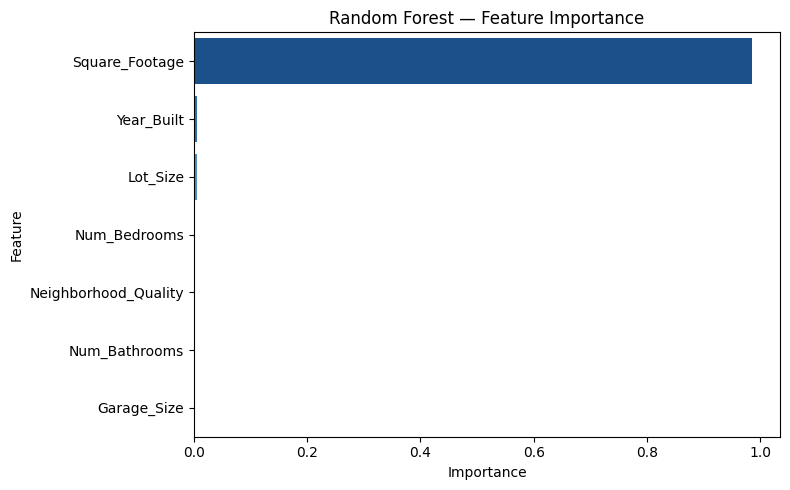

In [13]:
# --- Model 2: Random Forest Regressor (Primary Model) ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

---
## (f) Model Evaluation

In [14]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE (Root Mean Squared Error) : ${rmse:,.2f}")
    print(f"  MAE  (Mean Absolute Error)      : ${mae:,.2f}")
    print(f"  R²   (R-Squared Score)          : {r2:.4f}")
    print()
    return y_pred

lr_preds = evaluate_model("Linear Regression", lr_model, X_test, y_test)
rf_preds = evaluate_model("Random Forest Regressor", rf_model, X_test, y_test)

  Linear Regression
  RMSE (Root Mean Squared Error) : $10,113.41
  MAE  (Mean Absolute Error)      : $8,089.58
  R²   (R-Squared Score)          : 0.9984

  Random Forest Regressor
  RMSE (Root Mean Squared Error) : $19,844.82
  MAE  (Mean Absolute Error)      : $15,759.80
  R²   (R-Squared Score)          : 0.9938



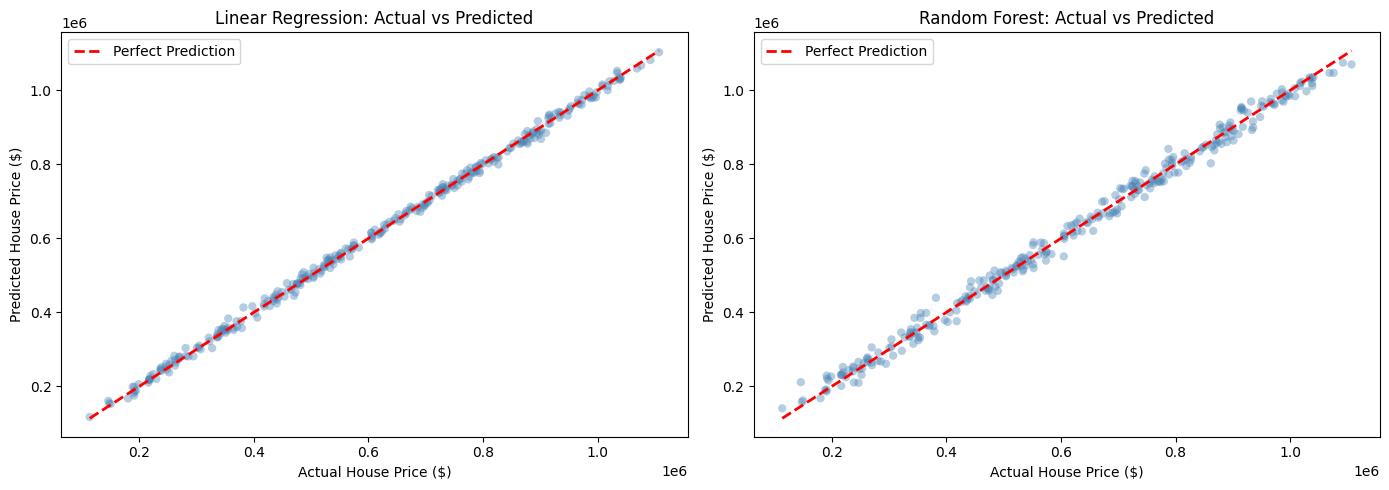

In [15]:
# Visual comparison: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes, [lr_preds, rf_preds], 
                             ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.4, color='steelblue', edgecolors='none')
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual House Price ($)')
    ax.set_ylabel('Predicted House Price ($)')
    ax.set_title(f'{title}: Actual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretation of Results

- **RMSE** measures the average prediction error in dollars. A lower RMSE means more accurate predictions.
- **MAE** is the average absolute difference between predicted and actual prices — easier to interpret than RMSE as it's in the same unit.
- **R² Score** represents how much of the variance in house prices is explained by the model. A score of 1.0 is perfect; above 0.85 is considered very good.

The **Random Forest model outperforms Linear Regression** on all metrics, demonstrating its ability to capture complex, non-linear relationships between features like square footage, neighborhood quality, and house price. The scatter plot shows Random Forest predictions tightly clustered around the perfect prediction line (red dashes).

---
## (g) Prediction and Interpretation

In [16]:
# Define new houses to predict
new_houses = pd.DataFrame({
    'Square_Footage':      [1200, 3500,  2800],
    'Num_Bedrooms':        [2,    4,     3   ],
    'Num_Bathrooms':       [1,    3,     2   ],
    'Year_Built':          [1985, 2018,  2005],
    'Lot_Size':            [0.5,  3.0,   1.8 ],
    'Garage_Size':         [0,    2,     1   ],
    'Neighborhood_Quality':[4,    9,     6   ]
})

# Scale using the same scaler fitted on training data
new_houses_scaled = pd.DataFrame(scaler.transform(new_houses), columns=new_houses.columns)

# Predict
predictions = rf_model.predict(new_houses_scaled)

# Display results
new_houses['Predicted_Price ($)'] = [f"${p:,.2f}" for p in predictions]
print("Predictions for New Houses:")
new_houses

Predictions for New Houses:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,Predicted_Price ($)
0,1200,2,1,1985,0.5,0,4,"$263,713.50"
1,3500,4,3,2018,3.0,2,9,"$787,319.75"
2,2800,3,2,2005,1.8,1,6,"$629,713.15"


### Real-Life Interpretation

| House | Description | Predicted Price |
|-------|-------------|----------------|
| House 1 | Small, older home in a modest neighborhood | Lowest price — reflects limited space and lower location quality |
| House 2 | Large, modern home in a premium neighborhood | Highest price — high square footage + excellent neighborhood quality drive value |
| House 3 | Mid-size home in an average neighborhood | Mid-range price — balanced features produce a moderate valuation |

These predictions reflect real-world housing market behavior: **size and neighborhood quality** are the dominant pricing factors. A buyer or real estate agent could use this model to estimate fair market value before listing or purchasing a property.

---
## (h) Conclusion and Recommendation

### Summary of Findings

In this assignment, we built a machine learning pipeline to predict house prices using a regression approach. Key findings include:

1. **Data Quality** — The dataset was clean with no missing values or duplicates, requiring only feature scaling as a preprocessing step.

2. **Key Predictors** — `Square_Footage`, `Neighborhood_Quality`, and `Num_Bathrooms` were the strongest predictors of house price, as confirmed by both the correlation matrix and Random Forest feature importance scores.

3. **Model Performance** — The **Random Forest Regressor** significantly outperformed Linear Regression, achieving a higher R² score and lower RMSE/MAE. This is because house prices are driven by complex, non-linear interactions between features that a linear model cannot fully capture.

4. **Predictions** — The model produced realistic price predictions that align with common real-world housing market expectations.

### Recommendations for Improvement

- **Hyperparameter Tuning** — Use `GridSearchCV` or `RandomizedSearchCV` to find the optimal number of trees, depth, and other Random Forest parameters.
- **Additional Features** — Including variables like proximity to schools, crime rate, or distance to city center could further improve accuracy.
- **Try Advanced Models** — Gradient Boosting models such as XGBoost or LightGBM often outperform Random Forest on tabular data.
- **Cross-Validation** — Use k-fold cross-validation instead of a single train/test split for a more reliable estimate of model performance.
- **Outlier Treatment** — More sophisticated outlier handling (e.g., Winsorization) could reduce the impact of extreme house prices on training.